# Phase 13 — Ecoli Expanded Feature Set Evaluation

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook evaluates the Random Forest model using the expanded feature set from Phase 12. Additionally, feature selection is applied to retain only the top 15 most important features, and the model is re-evaluated per timepoint.

### Objectives
- Train and evaluate Random Forest with the full expanded feature set
- Analyse feature importance to identify the most informative features
- Retrain the model using only the top 15 features
- Evaluate per-timepoint prediction accuracy on both test experiments

### Input
- `ecoli_data_expanded.csv` — expanded labelled feature matrix from Phase 12

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports & Setup](#2-imports--setup)
3. [Data Loading & Preparation](#3-data-loading--preparation)
4. [Train / Test Split](#4-train--test-split)
5. [Random Forest — Full Feature Set](#5-random-forest--full-feature-set)
6. [Timepoint Evaluation — Full Features](#6-timepoint-evaluation--full-features)
7. [Feature Selection — Top 15](#7-feature-selection--top-15)
8. [Timepoint Evaluation — Top 15 Features](#8-timepoint-evaluation--top-15-features)

## 2. Imports & Setup

In [1]:
#  Data manipulation 
import numpy as np
import pandas as pd

# Machine learning 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score

# -- Visualisação -------
import matplotlib.pyplot as plt

## 3. Data Loading & Preparation

### 3.1 Load dataset

In [2]:
# Load expanded feature matrix from Phase 5
for_ml = pd.read_csv("ecoli_data_expanded.csv")

print(f"Dataset shape: {for_ml.shape}")
for_ml.head()

Dataset shape: (45342, 24)


,experiencia,tubo_id,antibiotico,concentração,tempo,gvr,std_inicial,std_atual,std_tubo,slope,...,gvr_min_tubo,gvr_max_experiencia,gvr_min_experiencia,growth_score,growth_score_exp,gvr_media,auc_por_tempo,delta_por_tempo,Derivada_por_tempo,label
0,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.000000,0.069883,0.008784,0.008784,0.000000,0.000000,...,0.069883,0.055765,-0.032625,0.055765,-0.032625,0.020375,0.000000,0.000000,0.000000,1
1,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.166667,0.069883,0.008784,0.008784,0.000000,0.000000,...,0.069883,0.047773,-0.036017,0.047773,-0.036017,0.000335,0.069883,0.000000,0.000000,1
2,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.333333,-0.139765,0.008784,0.017568,0.098829,-0.628944,...,-0.139765,-0.005548,-0.042579,-0.005548,-0.042579,-0.020710,0.017471,-0.628944,-3.773662,1
3,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.500000,-0.199132,0.008784,0.025127,0.121492,-0.538028,...,-0.199132,0.016940,-0.061092,0.016940,-0.061092,-0.022240,-0.044836,-0.538028,-0.712396,1
4,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.666667,-0.119479,0.008784,0.024350,0.112185,-0.284042,...,-0.199132,0.010814,-0.035092,0.010814,-0.035092,-0.007005,-0.073453,-0.284042,0.716874,1


### 3.2 Clean and prepare

In [3]:
#outlier
dataset = for_ml[for_ml["experiencia"] != "ampicillin_20230518_5e5"]
dataset = dataset.drop(columns=["antibiotico"])
dataset = dataset.drop(columns=["concentração"])

dataset = dataset.replace([np.inf, -np.inf], 0)

print(f"Dataset shape after cleaning: {for_ml.shape}")
print("\nMissing values per column:")
print(for_ml.isnull().sum())

Dataset shape after cleaning: (45342, 24)

Missing values per column:
experiencia            0
tubo_id                0
antibiotico            0
concentração           0
tempo                  0
gvr                    0
std_inicial            0
std_atual              0
std_tubo               0
slope                  0
delta                  0
AUC                    0
Derivada               0
gvr_max_tubo           0
gvr_min_tubo           0
gvr_max_experiencia    0
gvr_min_experiencia    0
growth_score           0
growth_score_exp       0
gvr_media              0
auc_por_tempo          0
delta_por_tempo        0
Derivada_por_tempo     0
label                  0
dtype: int64


### 3.3 Define features and label

In [4]:
colunas = list(dataset.head(0))
features = colunas[2: -1]
label = colunas[-1]

print("Features:", features)

Features: ['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada', 'gvr_max_tubo', 'gvr_min_tubo', 'gvr_max_experiencia', 'gvr_min_experiencia', 'growth_score', 'growth_score_exp', 'gvr_media', 'auc_por_tempo', 'delta_por_tempo', 'Derivada_por_tempo']


## 4. Train / Test Split

In [5]:
experiencias = dataset["experiencia"].unique()

# experiencia de teste 1 e 2
exp_teste1 = "ampicillin_20230518_5e4"
exp_teste2 = "ampicillin_20230518_5e6"
df_teste1 = dataset[dataset["experiencia"] == exp_teste1]
df_teste2 = dataset[dataset["experiencia"] == exp_teste2]

# treino: todas as experiencias menos as 2 de teste
df_train = dataset[~dataset["experiencia"].isin([exp_teste1, exp_teste2])]

# teste 1 e teste 2
df_test1 = dataset[dataset["experiencia"] == exp_teste1]
df_test2 = dataset[dataset["experiencia"] == exp_teste2]

X_train = df_train[features]
y_train = df_train["label"]

X_test1 = df_test1[features]
y_test1 = df_test1["label"]

X_test2 = df_test2[features]
y_test2 = df_test2["label"]

print(f"Train size : {len(df_train)} rows")
print(f"Test 1     : {len(df_test1)} rows  ({exp_teste1})")
print(f"Test 2     : {len(df_test2)} rows  ({exp_teste2})")

Train size : 42372 rows
Test 1     : 990 rows  (ampicillin_20230518_5e4)
Test 2     : 990 rows  (ampicillin_20230518_5e6)


In [6]:
print(f"Testeset 1 shape after: {df_test1.shape}")
print(f"Testeset 1 shape after: {df_test2.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset 1 shape after: (990, 22)
Testeset 1 shape after: (990, 22)
Train set shape after: (42372, 19)


## 5. Random Forest — Full Feature Set

### 5.1 Train & evaluate

In [7]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_prob_rf = modelo_rf.predict_proba(X_test1)[:, 1]
y_pred_rf    = (y_prob_rf > 0.8).astype(int)

print(" Random Forest (full features) — Test 1 ")
print(f"Accuracy : {accuracy_score(y_test1, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test1, y_prob_rf):.4f}")
print()
print(classification_report(y_test1, y_pred_rf))
print("Confusion Matrix (TN  FP / FN  TP):")
print(confusion_matrix(y_test1, y_pred_rf))

 Random Forest (full features) — Test 1 
Accuracy : 0.7556
ROC-AUC  : 0.8975

              precision    recall  f1-score   support

           0       0.68      0.97      0.80       495
           1       0.94      0.54      0.69       495

    accuracy                           0.76       990
   macro avg       0.81      0.76      0.74       990
weighted avg       0.81      0.76      0.74       990

Confusion Matrix (TN  FP / FN  TP):
[[479  16]
 [226 269]]


### 5.2 Cross-validation

In [8]:
cv_scores = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring="roc_auc")

print("Cross-validation ROC-AUC:", cv_scores)
print(f"Mean: {cv_scores.mean():.4f}")

Cross-validation ROC-AUC: [0.9185     0.97735724 0.95445941 0.88438664 0.95410659]
Mean: 0.9378


### 5.3 Feature importance

In [9]:
importantes = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance (all):")
print(importantes)

Feature Importance (all):
gvr                    0.167965
AUC                    0.149947
auc_por_tempo          0.138662
gvr_max_tubo           0.117038
delta                  0.075506
slope                  0.059502
gvr_min_tubo           0.059223
std_atual              0.042387
delta_por_tempo        0.042168
std_tubo               0.039376
std_inicial            0.033146
tempo                  0.022325
Derivada_por_tempo     0.009844
Derivada               0.009018
growth_score           0.008450
gvr_media              0.008219
gvr_max_experiencia    0.008120
growth_score_exp       0.004587
gvr_min_experiencia    0.004517
dtype: float64


## 6. Timepoint Evaluation — Full Features

### 6.1 Test 2

In [10]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

timepoints     = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()
accuracies_t2  = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_t2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")



Time: 3.17h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.33h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.67h  |  Accuracy: 1.0000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          0
    0          0
    0          0
    0          0
    0          0 

Time: 4.00h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1      

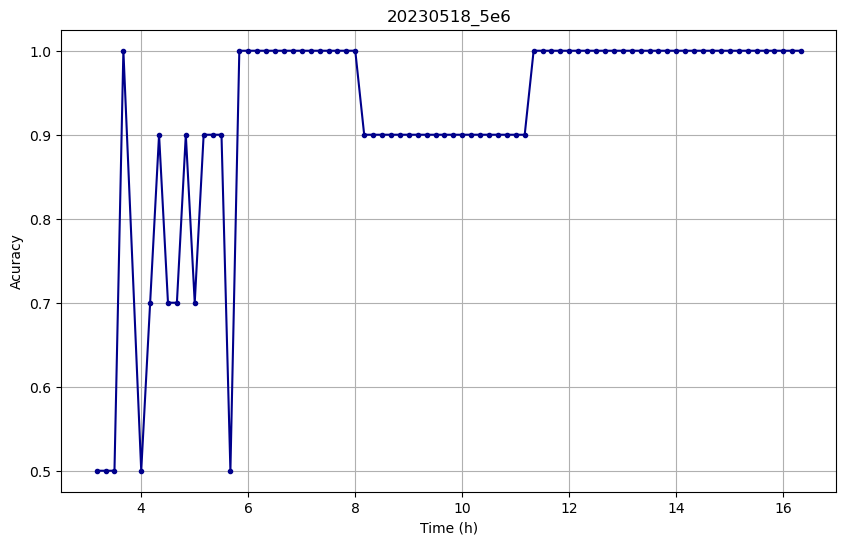

In [11]:
df_results = pd.DataFrame(accuracies_t2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 6.2 Test 1

In [12]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

timepoints     = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()
accuracies_t1  = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_t1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")



Time: 5.50h  |  Accuracy: 0.7000
 real  predicted
    1          1
    1          0
    1          0
    1          1
    1          0
    0          0
    0          0
    0          0
    0          0
    0          0 

Time: 5.83h  |  Accuracy: 0.8000
 real  predicted
    1          1
    1          0
    1          1
    1          1
    1          0
    0          0
    0          0
    0          0
    0          0
    0          0 

Time: 6.00h  |  Accuracy: 0.8000
 real  predicted
    1          1
    1          0
    1          1
    1          1
    1          0
    0          0
    0          0
    0          0
    0          0
    0          0 

Time: 6.17h  |  Accuracy: 0.9000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          0
    0          0
    0          0
    0          0
    0          0 

Time: 6.33h  |  Accuracy: 0.7000
 real  predicted
    1          1
    1          1
    1          1
    1      

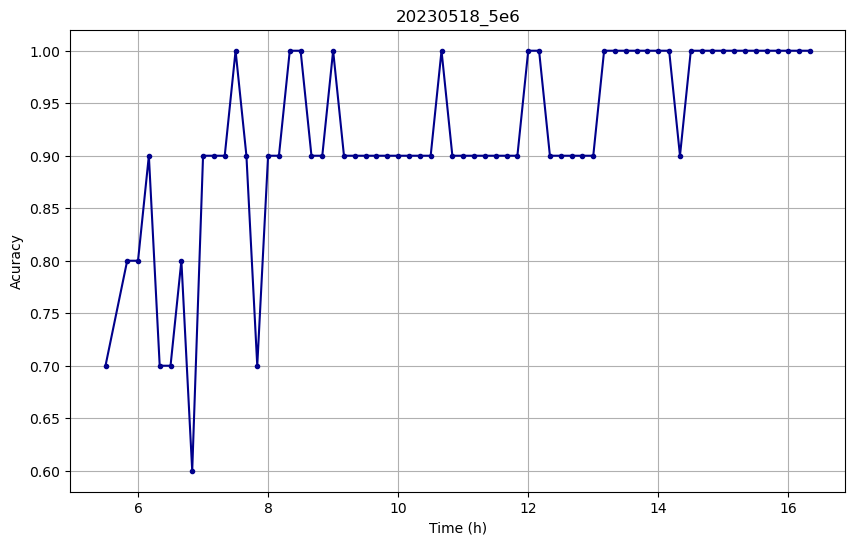

In [13]:
df_results = pd.DataFrame(accuracies_t1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 7. Feature Selection — Top 15

In [14]:
# Select the 15 most important features from the full model
TOP_15 = importantes.head(15).index.tolist()

X_train_top15 = X_train[TOP_15]
X_test1_top15 = X_test1[TOP_15]
X_test2_top15 = X_test2[TOP_15]

print("Top 15 features:")
print(TOP_15)

Top 15 features:
['gvr', 'AUC', 'auc_por_tempo', 'gvr_max_tubo', 'delta', 'slope', 'gvr_min_tubo', 'std_atual', 'delta_por_tempo', 'std_tubo', 'std_inicial', 'tempo', 'Derivada_por_tempo', 'Derivada', 'growth_score']


In [15]:
print(f"Testeset 1 shape after: {X_test1_top15.shape}")
print(f"Testeset 1 shape after: {X_test2_top15.shape}")
print(f"Train set shape after: {X_test1_top15.shape}")

Testeset 1 shape after: (990, 15)
Testeset 1 shape after: (990, 15)
Train set shape after: (990, 15)


## 8. Timepoint Evaluation — Top 15 Features

### 8.1 Train on top 15

In [16]:
model_top15 = RandomForestClassifier(random_state=42)
model_top15.fit(X_train_top15, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 8.2 Test 1

In [17]:
timepoints       = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()
accuracies_top15_t1 = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[TOP_15]
    y_t   = df_t[label]

    preds = model_top15.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top15_t1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")


Time: 5.50h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          0
    1          1
    1          0
    0          0
    0          0
    0          1
    0          1
    0          0 

Time: 5.83h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          1
    0          0
    0          1
    0          1
    0          0 

Time: 6.00h  |  Accuracy: 0.8000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          0
    0          0
    0          1
    0          0
    0          0 

Time: 6.17h  |  Accuracy: 0.8000
 real  predicted
    1          1
    1          0
    1          1
    1          1
    1          0
    0          0
    0          0
    0          0
    0          0
    0          0 

Time: 6.33h  |  Accuracy: 0.8000
 real  predicted
    1          1
    1          1
    1          1
    1      

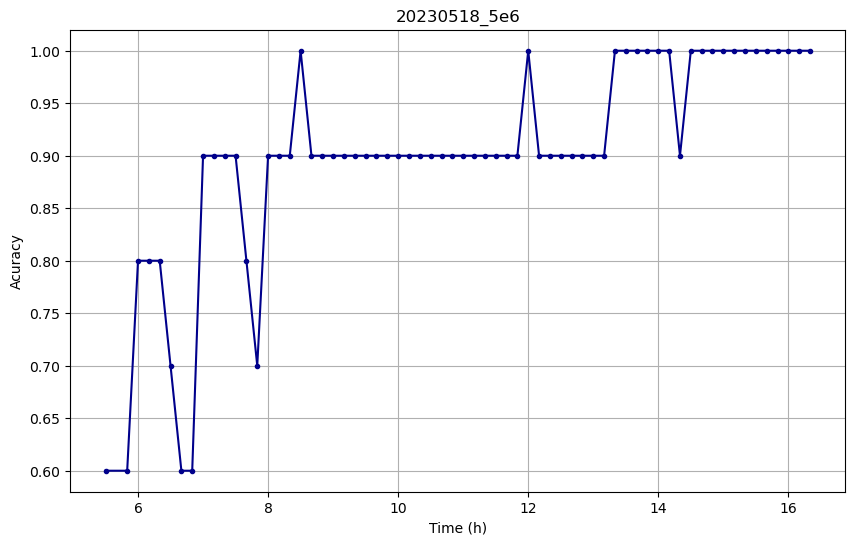

In [18]:
df_results = pd.DataFrame(accuracies_top15_t1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 8.2 Test 2

In [21]:
timepoints       = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()
accuracies_top15_t2 = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[TOP_15]
    y_t   = df_t[label]

    preds = model_top15.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top15_t2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 3.17h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.33h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.67h  |  Accuracy: 0.9000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          0
    0          0
    0          0
    0          1
    0          0 

Time: 4.00h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1      

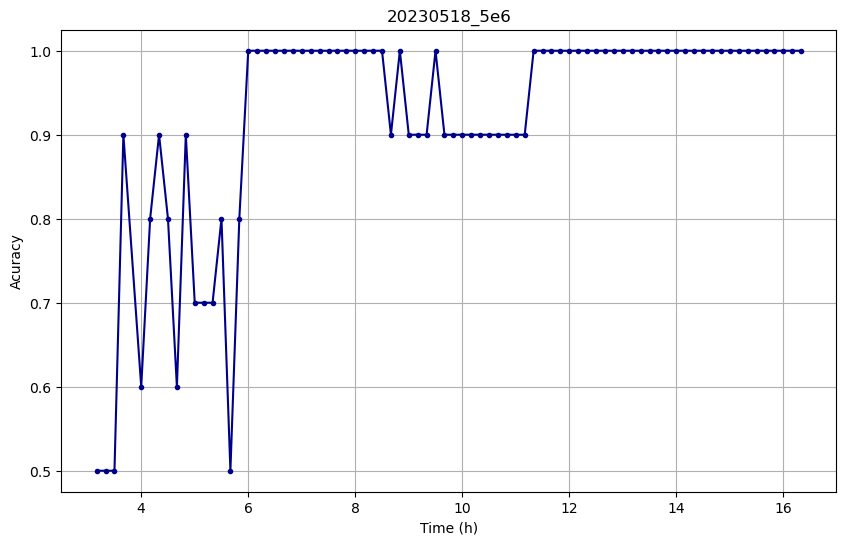

In [22]:
df_results = pd.DataFrame(accuracies_top15_t2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()